In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

from tqdm import tqdm  # Provides the progress of model running

In [3]:
housing = pd.read_csv('D:/Machine_Learning/Datasets/Housing.csv')
X , y = housing.drop('price', axis=1), housing['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state=26)

In [4]:
ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")

trans = ColumnTransformer(transformers=[("OHE", ohe, make_column_selector(dtype_include=object))], remainder="passthrough",
                            verbose_feature_names_out=False).set_output(transform="pandas")

X_trn_ohe = trans.fit_transform(X_train)
X_tst_ohe = trans.transform(X_test)

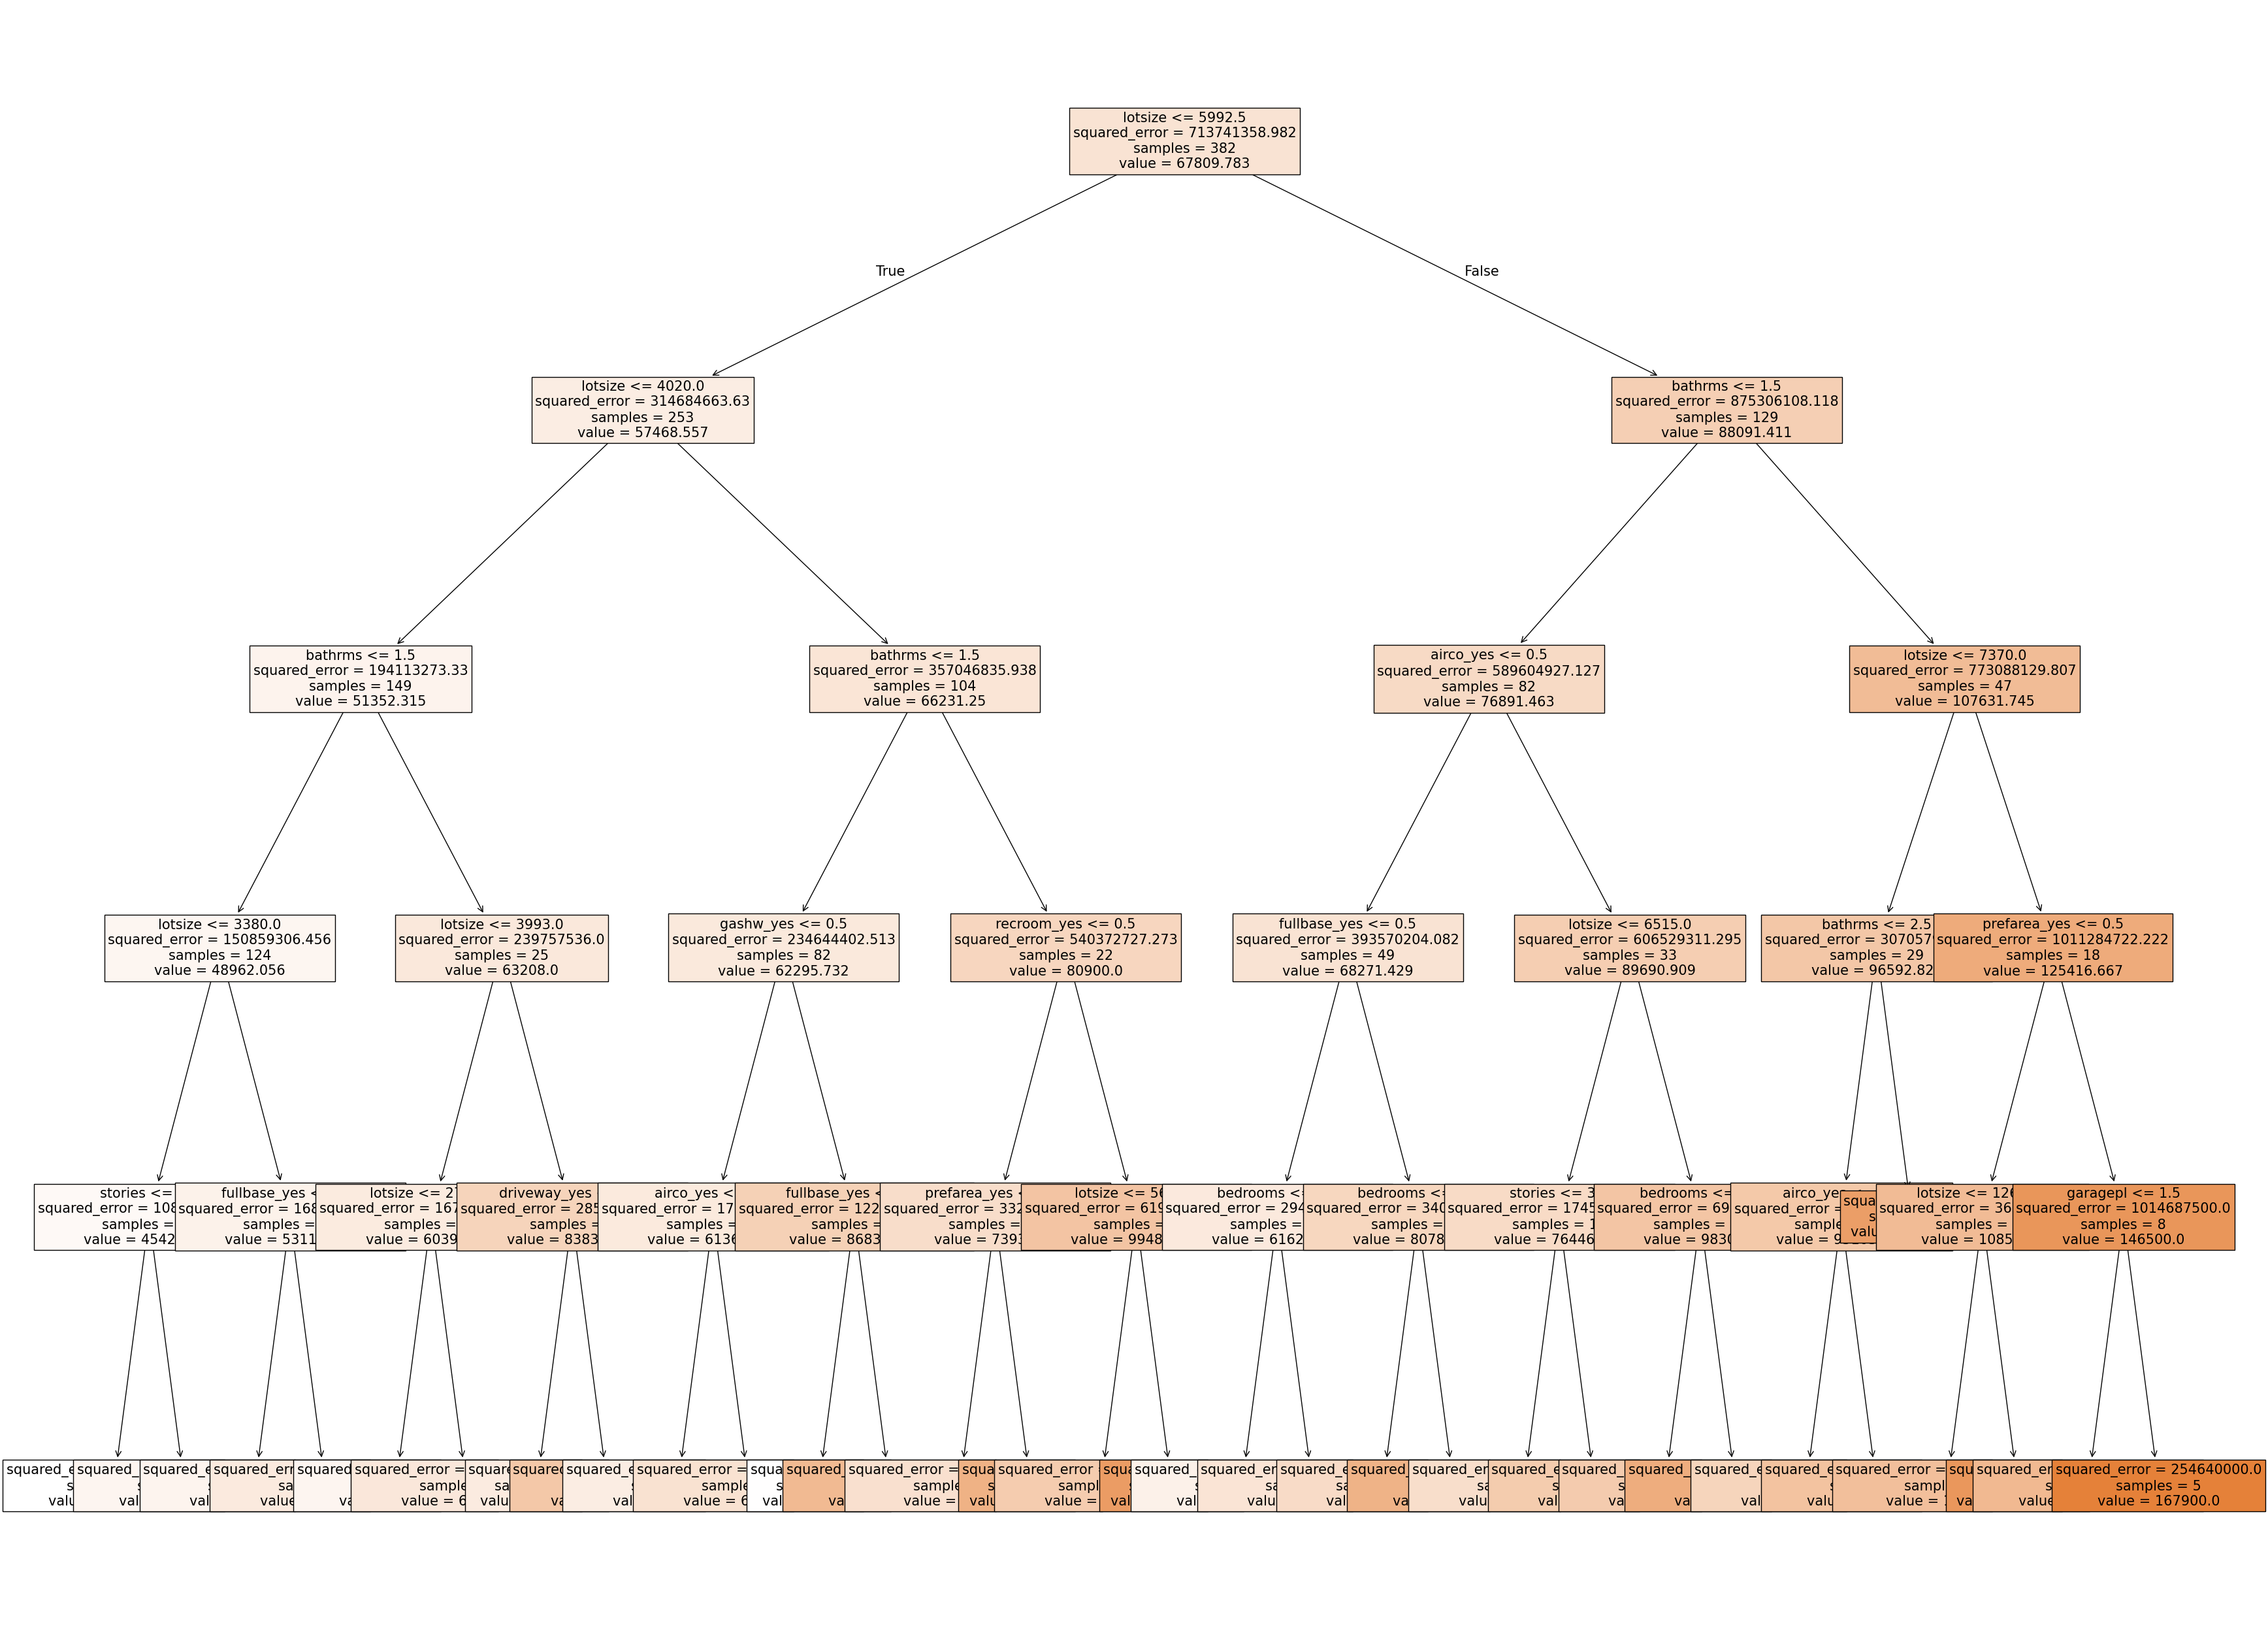

In [7]:
dtc = DecisionTreeRegressor(random_state=26, max_depth=5)
dtc.fit(X_trn_ohe, y_train)
plt.figure(figsize=(35,25))
plot_tree(dtc, feature_names=list(X_trn_ohe.columns), filled=True, fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
depths = np.arange(1,20)  # take random values instead of np.arange
splits = np.arange(2,100)
leaves= np.arange(1,100)
scores=[]

for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc = DecisionTreeRegressor(random_state=26, max_depth=d, min_samples_split=s, min_samples_leaf=l)
            
            dtc.fit(X_trn_ohe, y_train)
            y_pred = dtc.predict(X_tst_ohe)
            
            
            scores.append([d, s, l, r2_score(y_test, y_pred)])
    
df_scores = pd.DataFrame(scores, columns=['Depth', 'Splits', 'Leaves', 'R2 Score' ])
df_scores.sort_values(['R2 Score'], ascending=False).head()

 32%|██████████████████████████▏                                                        | 6/19 [03:11<06:59, 32.28s/it]

In [5]:
depths = [1,2,3,5,None]  # take random values instead of np.arange
splits = [2,4,8,10,20,30,50,100]
leaves= [1,4,8,10,20,30,46,50,100]
scores=[]

for d in tqdm(depths):
    for s in splits:
        for l in leaves:
            dtc = DecisionTreeRegressor(random_state=26, max_depth=d, min_samples_split=s, min_samples_leaf=l)
            
            dtc.fit(X_trn_ohe, y_train)
            y_pred = dtc.predict(X_tst_ohe)
            
            
            scores.append([d, s, l, r2_score(y_test, y_pred)])
    
df_scores = pd.DataFrame(scores, columns=['Depth', 'Splits', 'Leaves', 'R2 Score' ])
df_scores.sort_values(['R2 Score'], ascending=False).head()

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.71it/s]


,Depth,Splits,Leaves,R2 Score
274,5.0,50,20,0.530931
346,NaN,50,20,0.530931
272,5.0,50,8,0.528372
273,5.0,50,10,0.528372
343,NaN,50,4,0.528372


# best tree

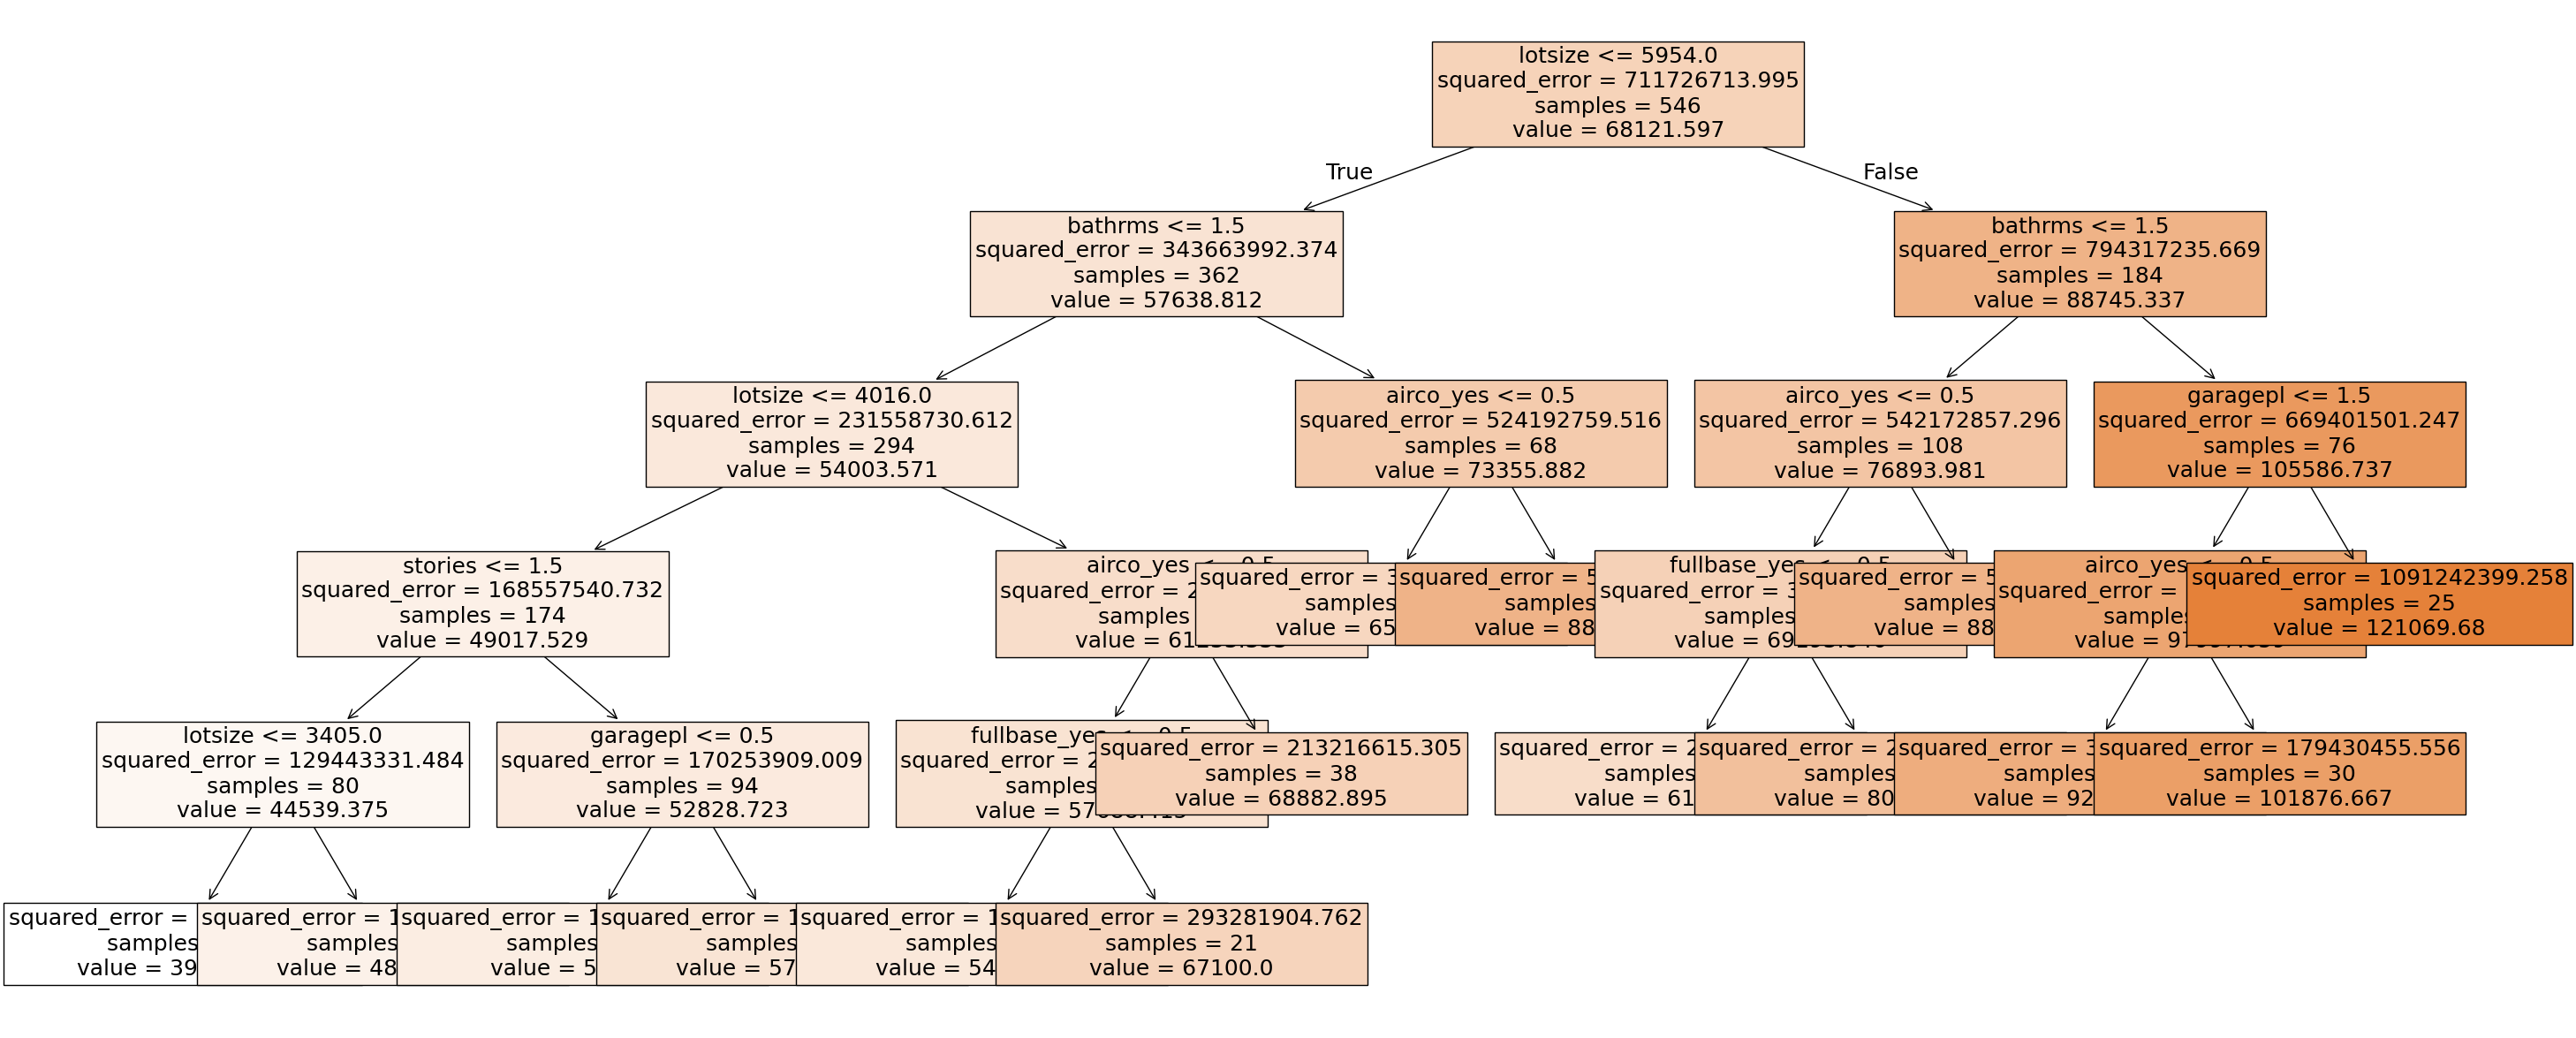

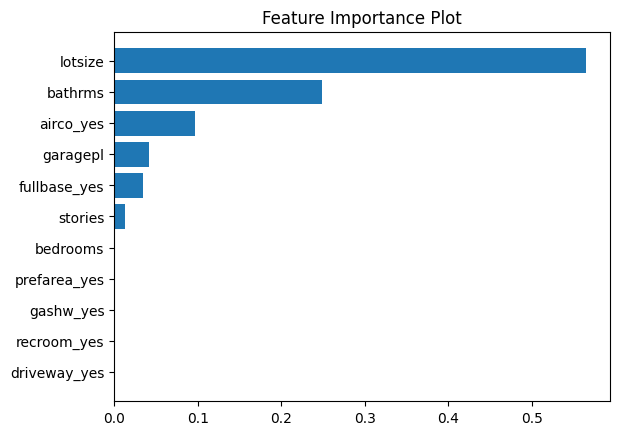

In [6]:
bm =  DecisionTreeRegressor(random_state=26, max_depth=5, min_samples_split=50, min_samples_leaf=20)

X_ohe = trans.fit_transform(X)

bm.fit(X_ohe,y)
plt.figure(figsize=(35,15))
plot_tree(bm, feature_names=list(X_ohe.columns), filled=True, fontsize=18)
plt.show()

df_imp = pd.DataFrame({'feature':X_ohe.columns, 'importance':bm.feature_importances_})
df_imp = df_imp.sort_values('importance')
plt.barh(df_imp['feature'], df_imp['importance'])
plt.title("Feature Importance Plot")
plt.show()